<a href="https://www.kaggle.com/code/omborse771924/consumer-shopping-analysis-100-accuracy?scriptVersionId=345415145" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harpartapsingh13/consumer-shopping-behavior-and-buying-survey-dataset/consumer_shopping_behavior_survey.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/harpartapsingh13/consumer-shopping-behavior-and-buying-survey-dataset/consumer_shopping_behavior_survey.csv')

In [3]:
df.head()

,Response_ID,Timestamp,Age,Gender,Occupation_Status,Country_Region,Monthly_Income_Range,Shop_Most_Where,Online_Shopping_Frequency,Preferred_Platform,...,Return_Frequency,Avg_Monthly_Spend_NonEssentials,Preferred_Payment_Method,Uses_BNPL_Installments,Online_Shopping_Satisfaction_Score,Trust_In_Online_Reviews_Score,Regret_After_Purchase_Frequency,Reason_Prefer_Online,Reason_Prefer_InStore,Best_Shopping_Mode
0,1,01/08/2026 12:30:25,20,Male,NaN,Philippines,"Under $1,000",Equal mix,Often,Physical stores,...,Never,Under $50,Digital wallet,"Yes, occasionally",6.0,7.0,2.0,More variety,No delivery wait,Online
1,2,21/06/2026 13:52:02,24,Male,Employed part-time,Brazil,"Under $1,000",In-store only,Often,Local e-commerce,...,Often,Under $50,Digital wallet,"No, never",5.0,8.0,3.0,NaN,Try product before buying,Offline
2,3,15/08/2026 04:24:18,22,Female,Student,India,"Under $1,000",Equal mix,Always,Local e-commerce,...,Sometimes,$150-300,Credit Card,"No, never",7.0,6.0,2.0,Better prices,Trust,Online
3,4,23/06/2026 21:24:21,20,Male,Student,NaN,"Under $1,000",In-store only,Occasionally,Brand websites,...,Never,Under $50,Debit Card,"No, never",8.0,7.0,3.0,Better prices,Try product before buying,Equal / both
4,5,20/08/2026 16:24:47,41,Male,Employed full-time,United States,"$1,000-3,000",Equal mix,Occasionally,NaN,...,Sometimes,$50-150,Debit Card,"No, never",6.0,8.0,2.0,Convenience,Trust,Equal / both


In [4]:
df.tail

<bound method NDFrame.tail of      Response_ID            Timestamp  Age             Gender  \
0              1  01/08/2026 12:30:25   20               Male   
1              2  21/06/2026 13:52:02   24               Male   
2              3  15/08/2026 04:24:18   22             Female   
3              4  23/06/2026 21:24:21   20               Male   
4              5  20/08/2026 16:24:47   41               Male   
..           ...                  ...  ...                ...   
495          496  18/07/2026 23:18:07   42             Female   
496          497  28/06/2026 15:20:50   22  Prefer not to say   
497          498  23/06/2026 05:27:31   26               Male   
498          499  17/07/2026 08:05:20   37             Female   
499          500  14/07/2026 11:16:14  NaN             Female   

      Occupation_Status  Country_Region Monthly_Income_Range Shop_Most_Where  \
0                   NaN     Philippines         Under $1,000       Equal mix   
1    Employed part-time      

In [5]:
df.info

<bound method DataFrame.info of      Response_ID            Timestamp  Age             Gender  \
0              1  01/08/2026 12:30:25   20               Male   
1              2  21/06/2026 13:52:02   24               Male   
2              3  15/08/2026 04:24:18   22             Female   
3              4  23/06/2026 21:24:21   20               Male   
4              5  20/08/2026 16:24:47   41               Male   
..           ...                  ...  ...                ...   
495          496  18/07/2026 23:18:07   42             Female   
496          497  28/06/2026 15:20:50   22  Prefer not to say   
497          498  23/06/2026 05:27:31   26               Male   
498          499  17/07/2026 08:05:20   37             Female   
499          500  14/07/2026 11:16:14  NaN             Female   

      Occupation_Status  Country_Region Monthly_Income_Range Shop_Most_Where  \
0                   NaN     Philippines         Under $1,000       Equal mix   
1    Employed part-time    

In [6]:
df.describe

<bound method NDFrame.describe of      Response_ID            Timestamp  Age             Gender  \
0              1  01/08/2026 12:30:25   20               Male   
1              2  21/06/2026 13:52:02   24               Male   
2              3  15/08/2026 04:24:18   22             Female   
3              4  23/06/2026 21:24:21   20               Male   
4              5  20/08/2026 16:24:47   41               Male   
..           ...                  ...  ...                ...   
495          496  18/07/2026 23:18:07   42             Female   
496          497  28/06/2026 15:20:50   22  Prefer not to say   
497          498  23/06/2026 05:27:31   26               Male   
498          499  17/07/2026 08:05:20   37             Female   
499          500  14/07/2026 11:16:14  NaN             Female   

      Occupation_Status  Country_Region Monthly_Income_Range Shop_Most_Where  \
0                   NaN     Philippines         Under $1,000       Equal mix   
1    Employed part-time  

In [7]:
df.isnull

<bound method DataFrame.isnull of      Response_ID            Timestamp  Age             Gender  \
0              1  01/08/2026 12:30:25   20               Male   
1              2  21/06/2026 13:52:02   24               Male   
2              3  15/08/2026 04:24:18   22             Female   
3              4  23/06/2026 21:24:21   20               Male   
4              5  20/08/2026 16:24:47   41               Male   
..           ...                  ...  ...                ...   
495          496  18/07/2026 23:18:07   42             Female   
496          497  28/06/2026 15:20:50   22  Prefer not to say   
497          498  23/06/2026 05:27:31   26               Male   
498          499  17/07/2026 08:05:20   37             Female   
499          500  14/07/2026 11:16:14  NaN             Female   

      Occupation_Status  Country_Region Monthly_Income_Range Shop_Most_Where  \
0                   NaN     Philippines         Under $1,000       Equal mix   
1    Employed part-time  

In [8]:
df.isnull().sum()

Response_ID                            0
Timestamp                              0
Age                                   22
Gender                                16
Occupation_Status                     21
Country_Region                        20
Monthly_Income_Range                  21
Shop_Most_Where                       16
Online_Shopping_Frequency             19
Preferred_Platform                    14
Primary_Device                         8
Top_Spending_Category                 24
Review_Influence_Score                15
Social_Ads_Influence_Score            21
Price_Comparison_Frequency            26
Discount_Importance_Score             23
Follows_Brands_On_Social              11
Likely_To_Buy_After_Ad_Score          25
Makes_Shopping_List                   24
Impulse_Purchase_Frequency            16
Return_Frequency                      17
Avg_Monthly_Spend_NonEssentials       20
Preferred_Payment_Method              15
Uses_BNPL_Installments                12
Online_Shopping_

In [9]:
# ============================================================
# HANDLE NULL VALUES
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Check NULL VALUES BEFORE HANDLING
# ------------------------------------------------------------

print("=" * 70)
print("NULL VALUES BEFORE HANDLING")
print("=" * 70)

print(df.isnull().sum())


# ------------------------------------------------------------
# 2. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ------------------------------------------------------------

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()


print("\nNumerical Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)


# ------------------------------------------------------------
# 3. HANDLE NUMERICAL NULL VALUES
# ------------------------------------------------------------

# Use median because it is less affected by extreme values.

for col in numeric_columns:

    if df[col].isnull().sum() > 0:

        df[col] = df[col].fillna(
            df[col].median()
        )


# ------------------------------------------------------------
# 4. HANDLE CATEGORICAL NULL VALUES
# ------------------------------------------------------------

# Use the most frequent value (mode).

for col in categorical_columns:

    if df[col].isnull().sum() > 0:

        mode_value = df[col].mode()

        if len(mode_value) > 0:

            df[col] = df[col].fillna(
                mode_value.iloc[0]
            )

        else:

            df[col] = df[col].fillna(
                "Unknown"
            )


# ------------------------------------------------------------
# 5. CHECK NULL VALUES AFTER HANDLING
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NULL VALUES AFTER HANDLING")
print("=" * 70)

print(df.isnull().sum())


# ------------------------------------------------------------
# 6. TOTAL REMAINING NULL VALUES
# ------------------------------------------------------------

total_nulls = df.isnull().sum().sum()

print("\nTotal remaining NULL values:", total_nulls)


# ------------------------------------------------------------
# 7. VERIFY DATASET
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET AFTER NULL VALUE HANDLING")
print("=" * 70)

print(df.head())

print("\nDataset Shape:")
print(df.shape)

NULL VALUES BEFORE HANDLING
Response_ID                            0
Timestamp                              0
Age                                   22
Gender                                16
Occupation_Status                     21
Country_Region                        20
Monthly_Income_Range                  21
Shop_Most_Where                       16
Online_Shopping_Frequency             19
Preferred_Platform                    14
Primary_Device                         8
Top_Spending_Category                 24
Review_Influence_Score                15
Social_Ads_Influence_Score            21
Price_Comparison_Frequency            26
Discount_Importance_Score             23
Follows_Brands_On_Social              11
Likely_To_Buy_After_Ad_Score          25
Makes_Shopping_List                   24
Impulse_Purchase_Frequency            16
Return_Frequency                      17
Avg_Monthly_Spend_NonEssentials       20
Preferred_Payment_Method              15
Uses_BNPL_Installments       

In [10]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['Response_ID', 'Timestamp', 'Age', 'Gender', 'Occupation_Status',
       'Country_Region', 'Monthly_Income_Range', 'Shop_Most_Where',
       'Online_Shopping_Frequency', 'Preferred_Platform', 'Primary_Device',
       'Top_Spending_Category', 'Review_Influence_Score',
       'Social_Ads_Influence_Score', 'Price_Comparison_Frequency',
       'Discount_Importance_Score', 'Follows_Brands_On_Social',
       'Likely_To_Buy_After_Ad_Score', 'Makes_Shopping_List',
       'Impulse_Purchase_Frequency', 'Return_Frequency',
       'Avg_Monthly_Spend_NonEssentials', 'Preferred_Payment_Method',
       'Uses_BNPL_Installments', 'Online_Shopping_Satisfaction_Score',
       'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency',
       'Reason_Prefer_Online', 'Reason_Prefer_InStore', 'Best_Shopping_Mode'],
      dtype='object')

## EDA

DATASET SHAPE
(500, 30)

Columns:
['Response_ID', 'Timestamp', 'Age', 'Gender', 'Occupation_Status', 'Country_Region', 'Monthly_Income_Range', 'Shop_Most_Where', 'Online_Shopping_Frequency', 'Preferred_Platform', 'Primary_Device', 'Top_Spending_Category', 'Review_Influence_Score', 'Social_Ads_Influence_Score', 'Price_Comparison_Frequency', 'Discount_Importance_Score', 'Follows_Brands_On_Social', 'Likely_To_Buy_After_Ad_Score', 'Makes_Shopping_List', 'Impulse_Purchase_Frequency', 'Return_Frequency', 'Avg_Monthly_Spend_NonEssentials', 'Preferred_Payment_Method', 'Uses_BNPL_Installments', 'Online_Shopping_Satisfaction_Score', 'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency', 'Reason_Prefer_Online', 'Reason_Prefer_InStore', 'Best_Shopping_Mode']


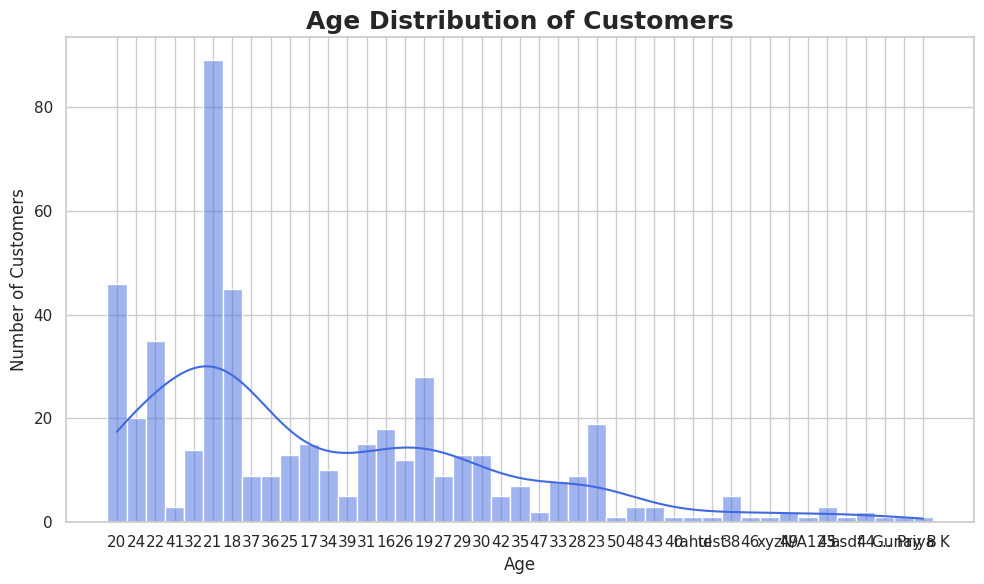

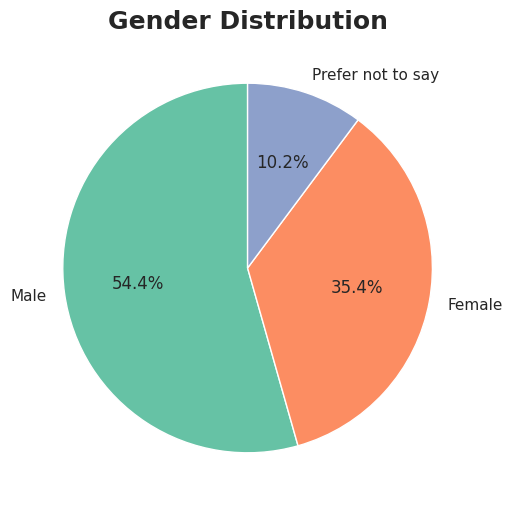

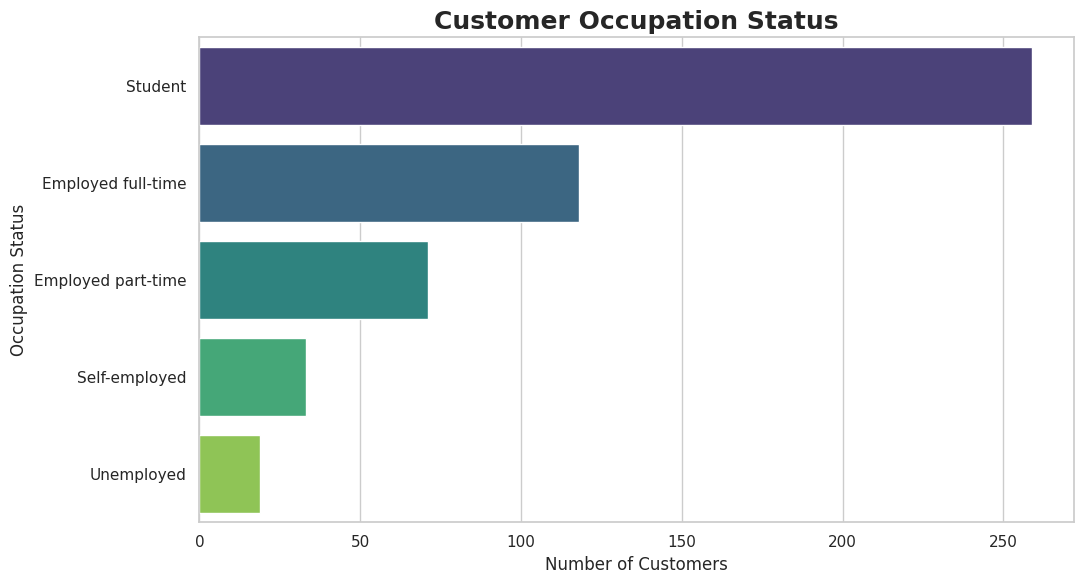

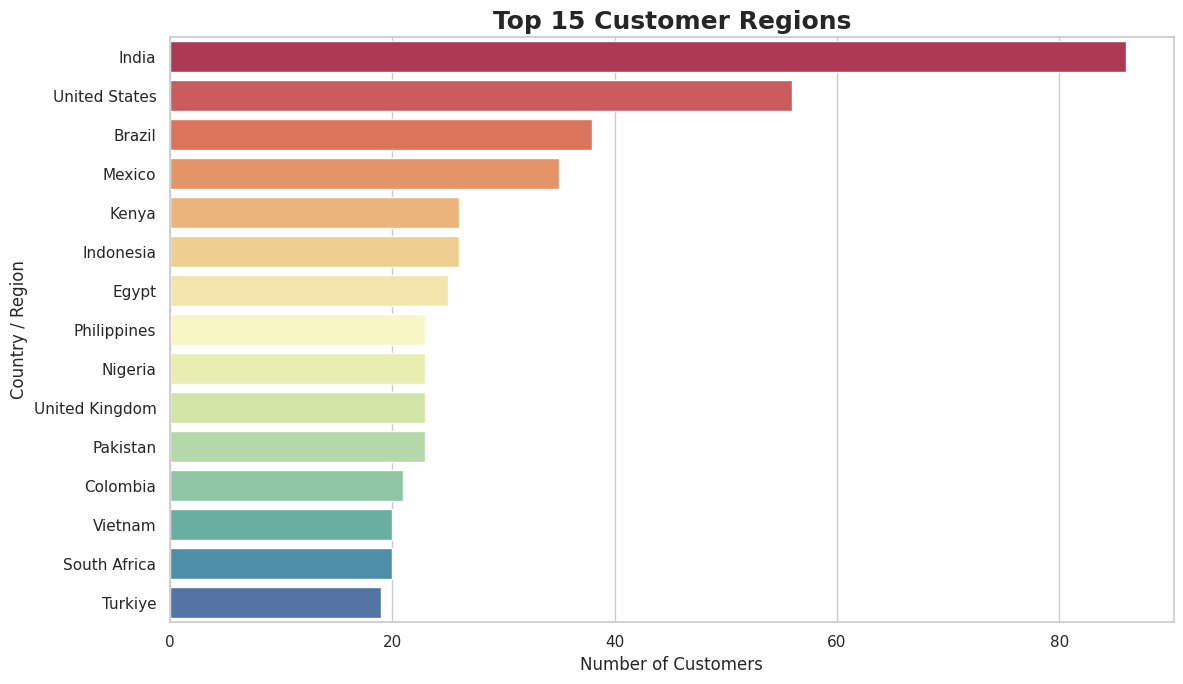

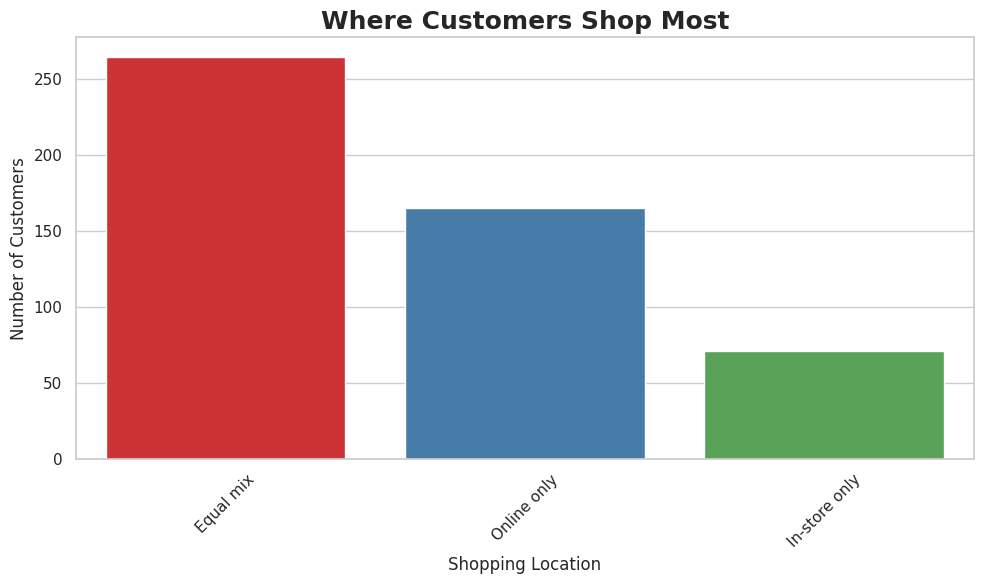

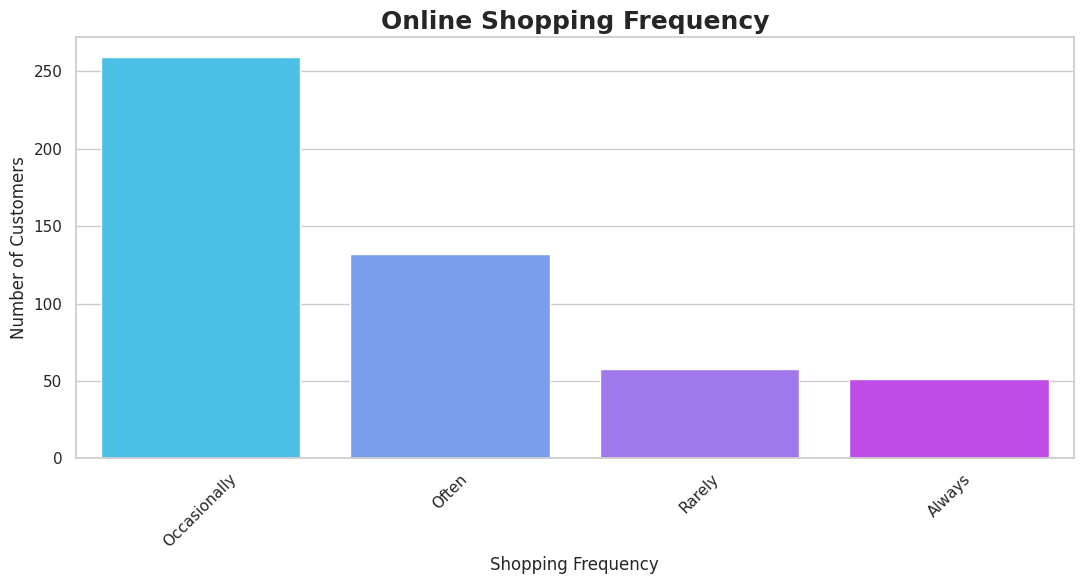

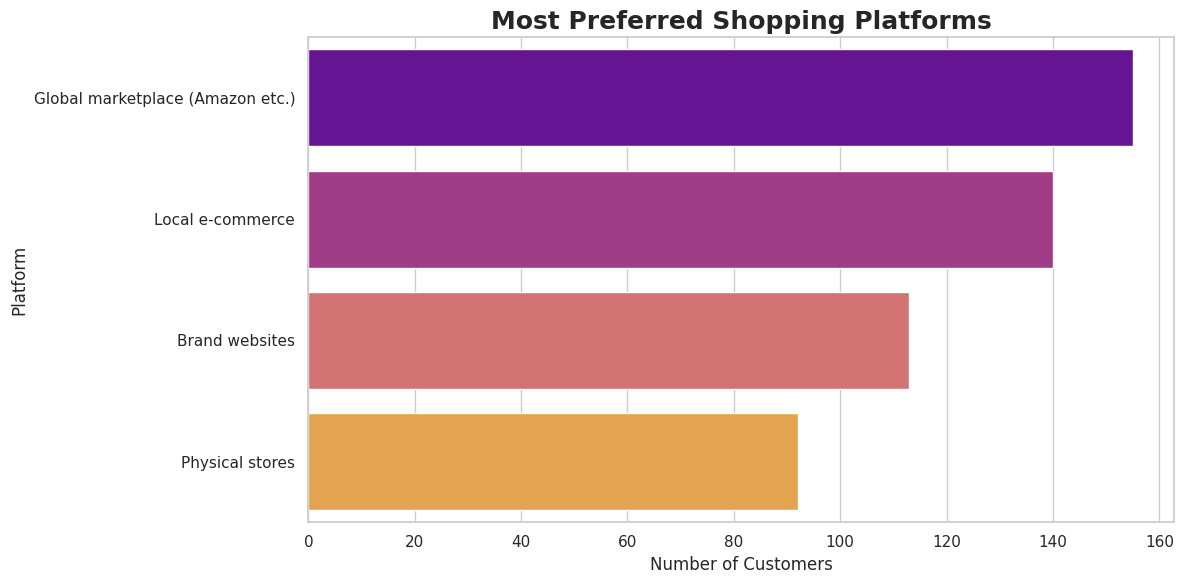

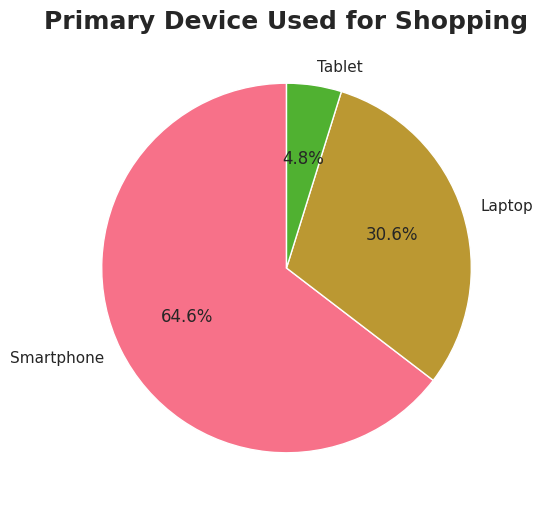

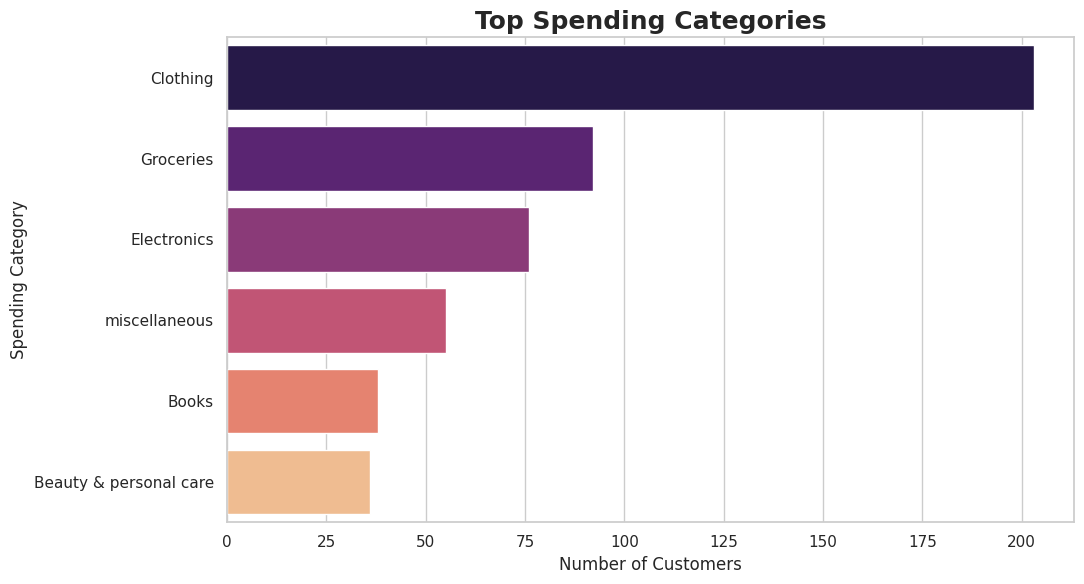

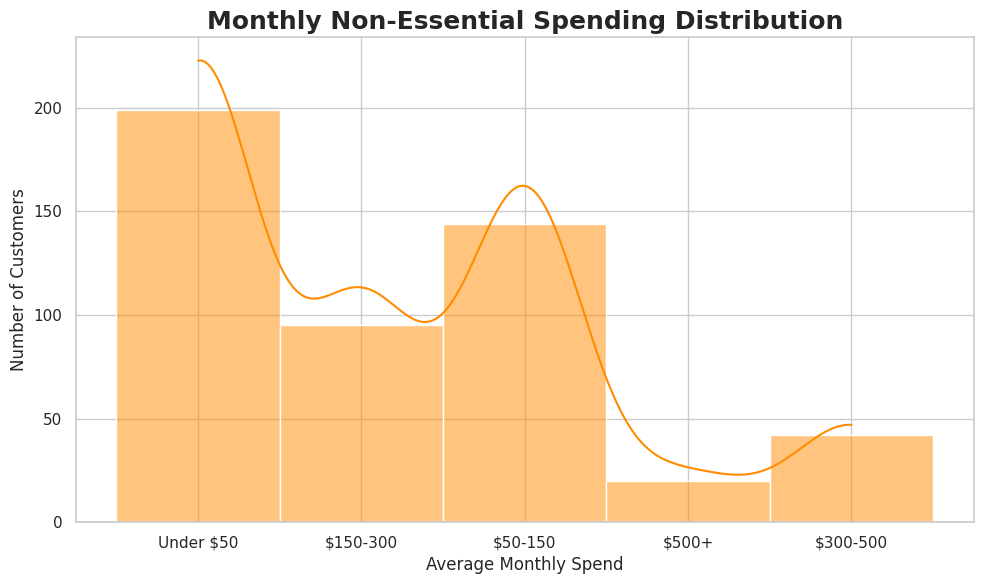

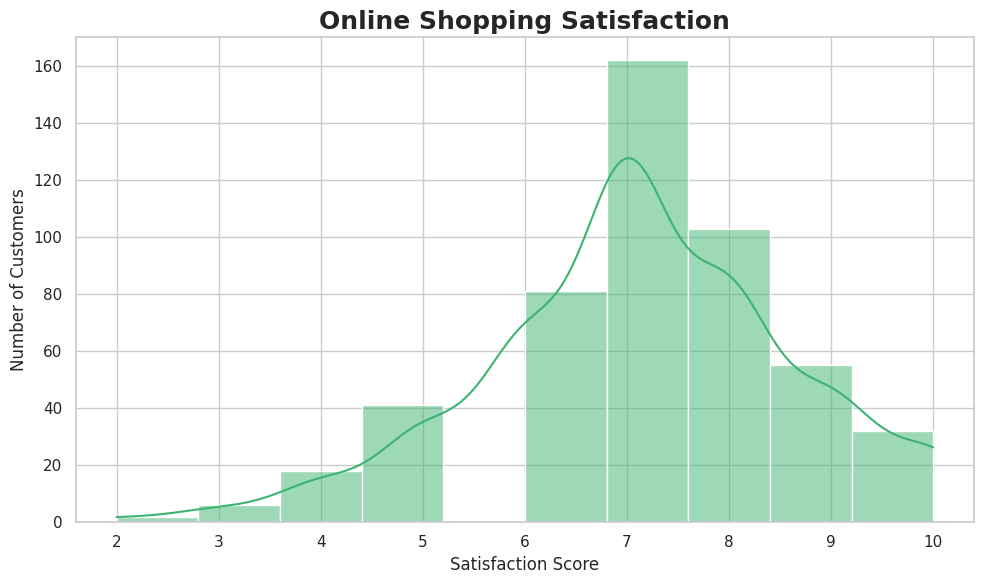

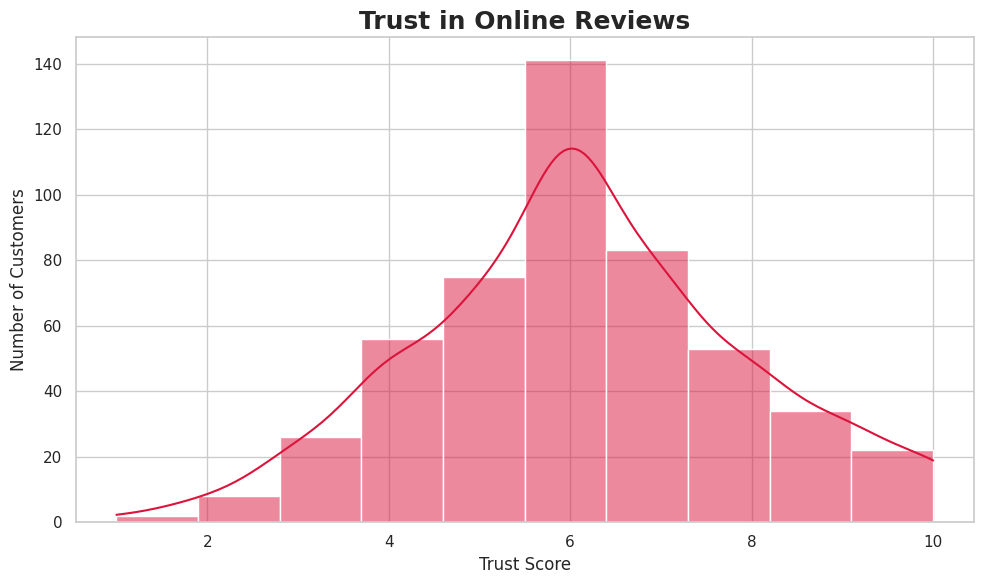

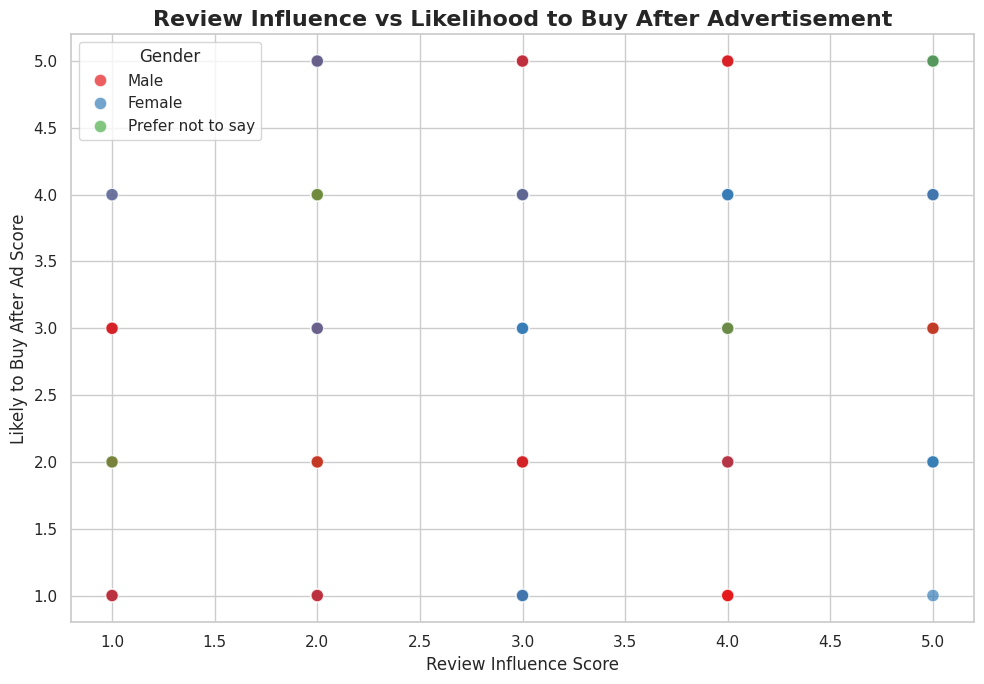

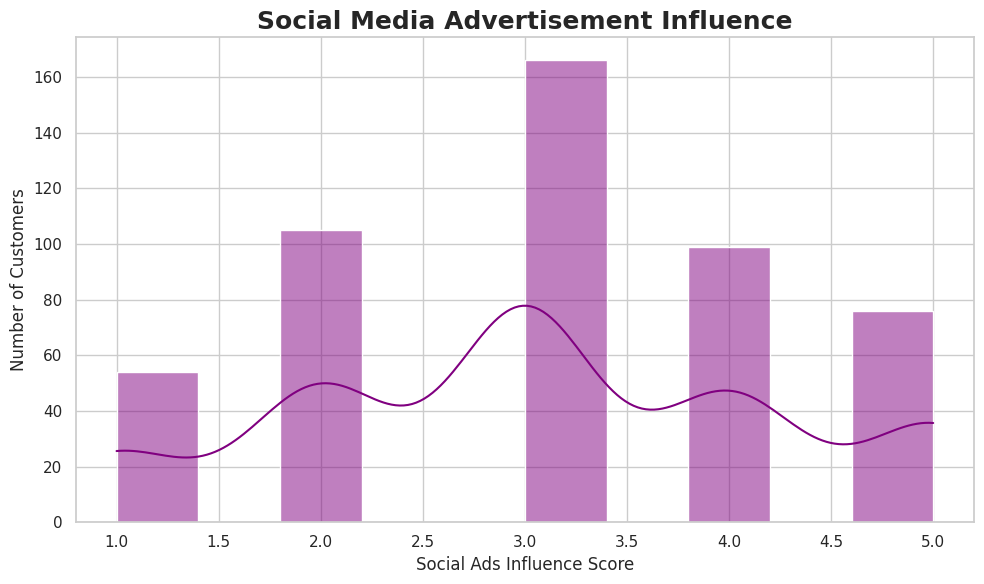

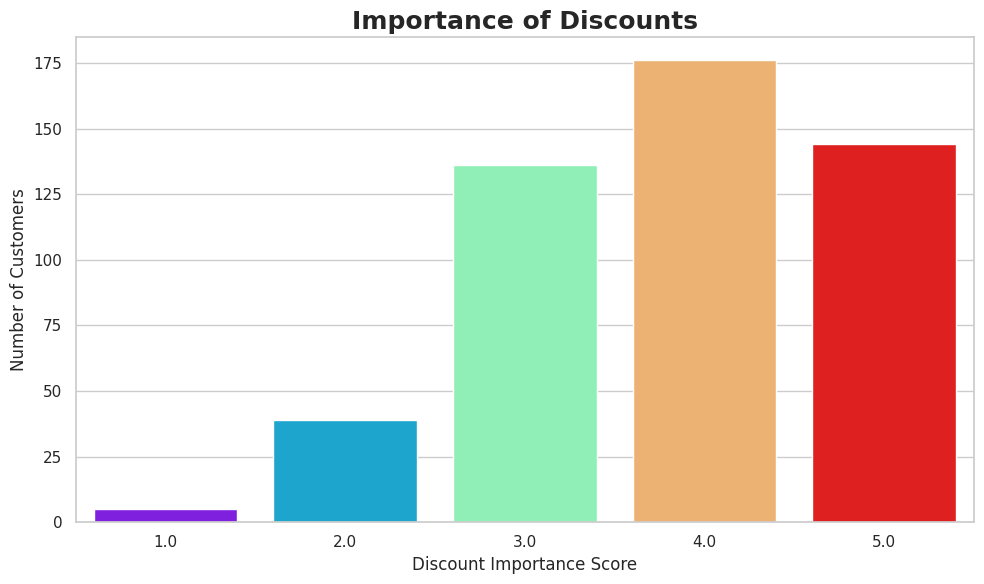

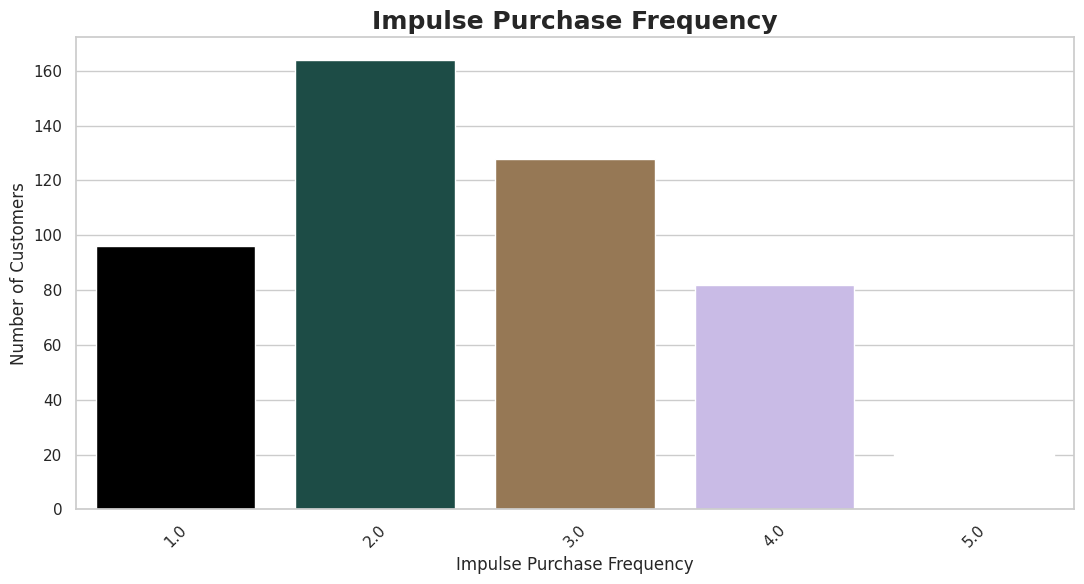

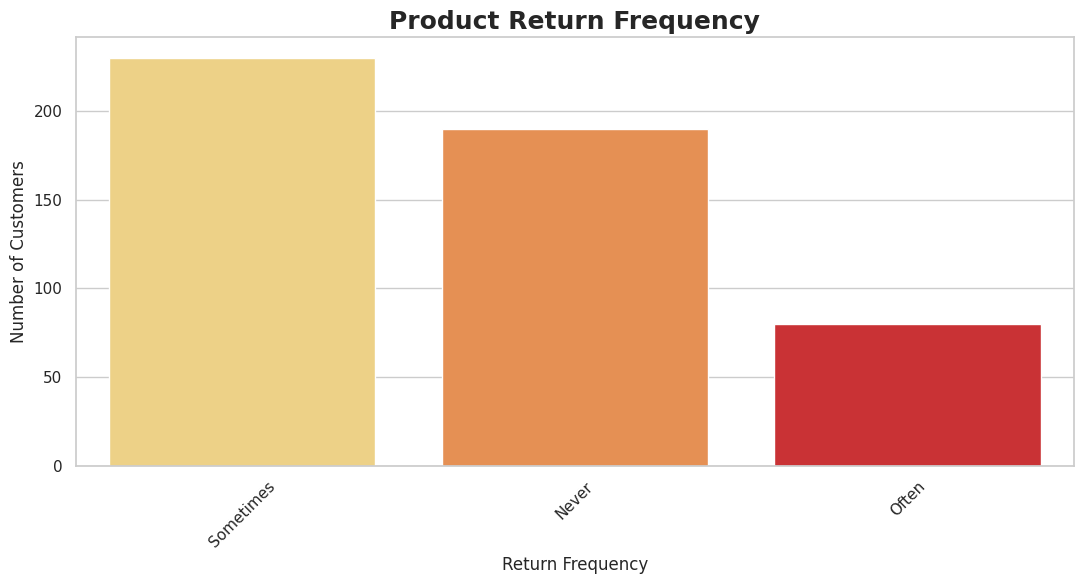

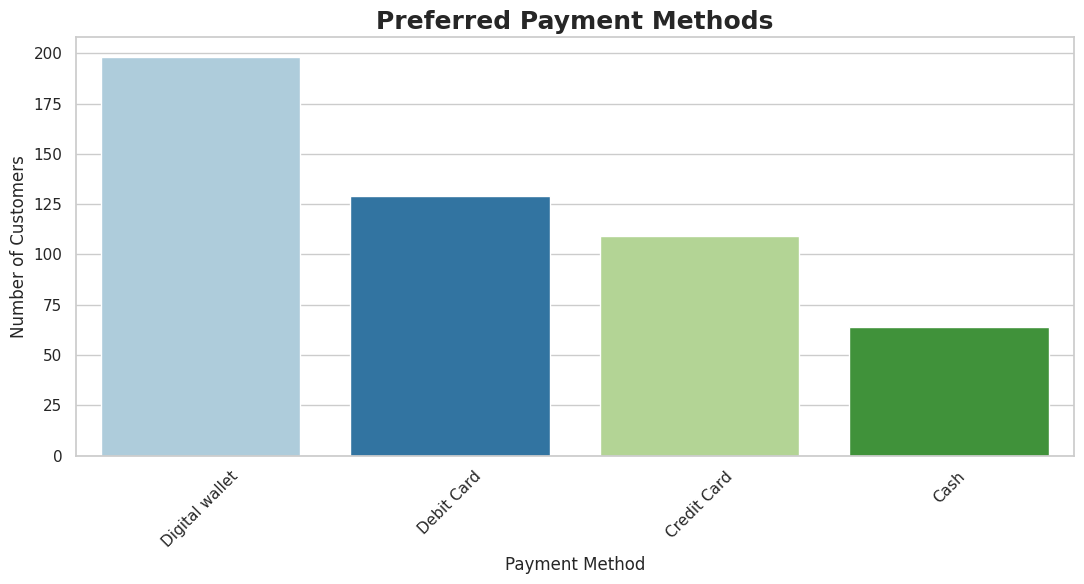

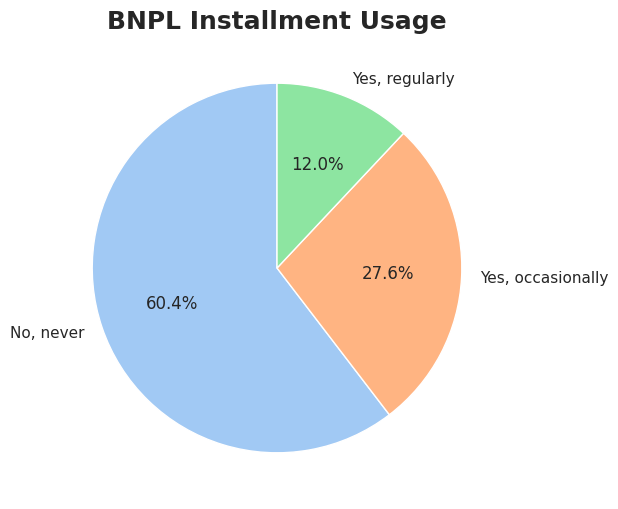

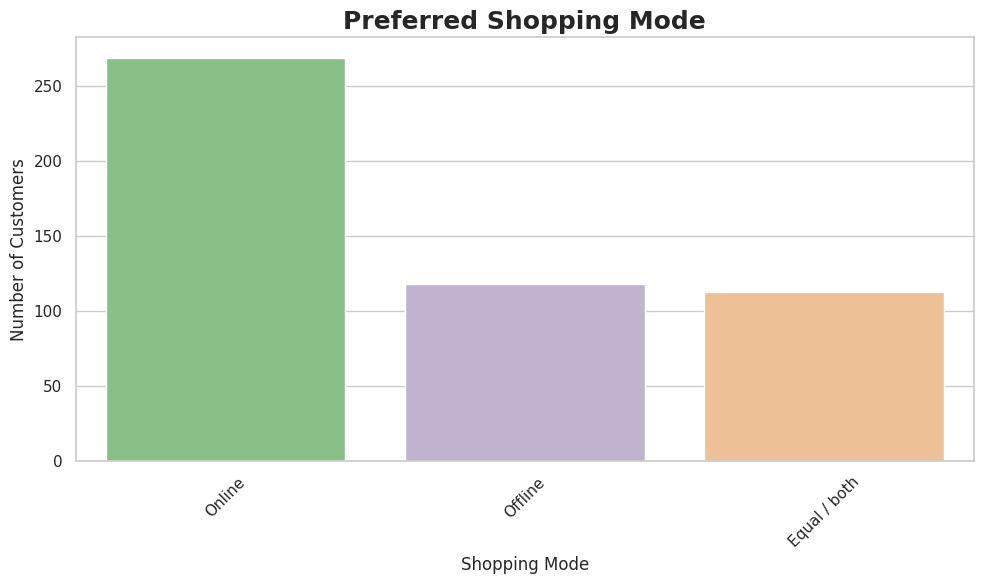

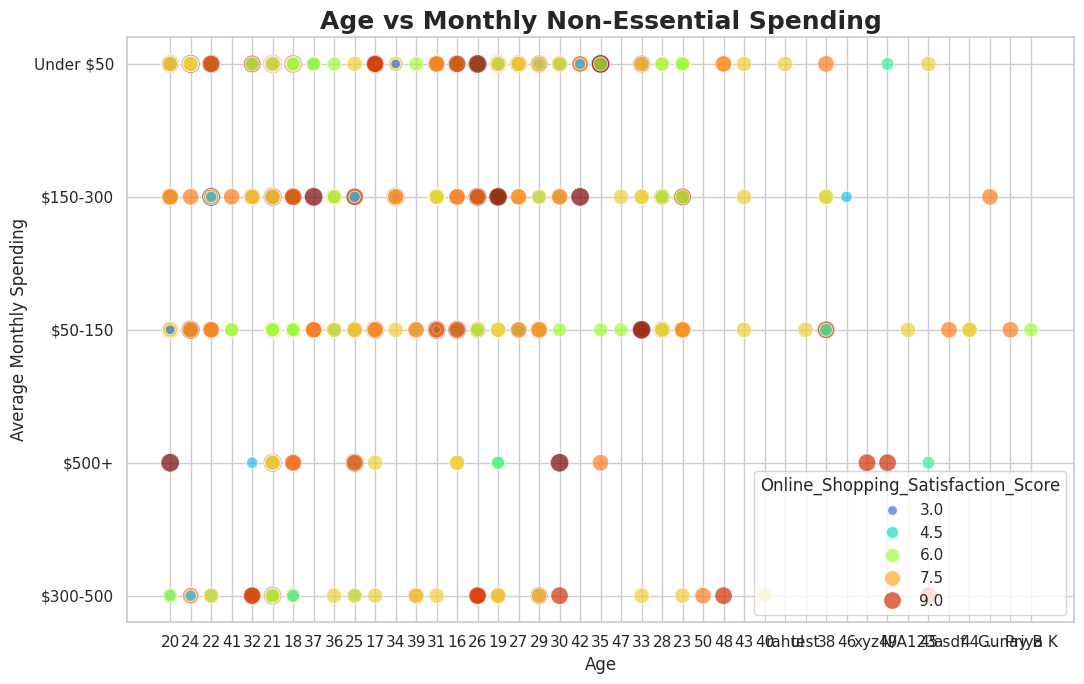

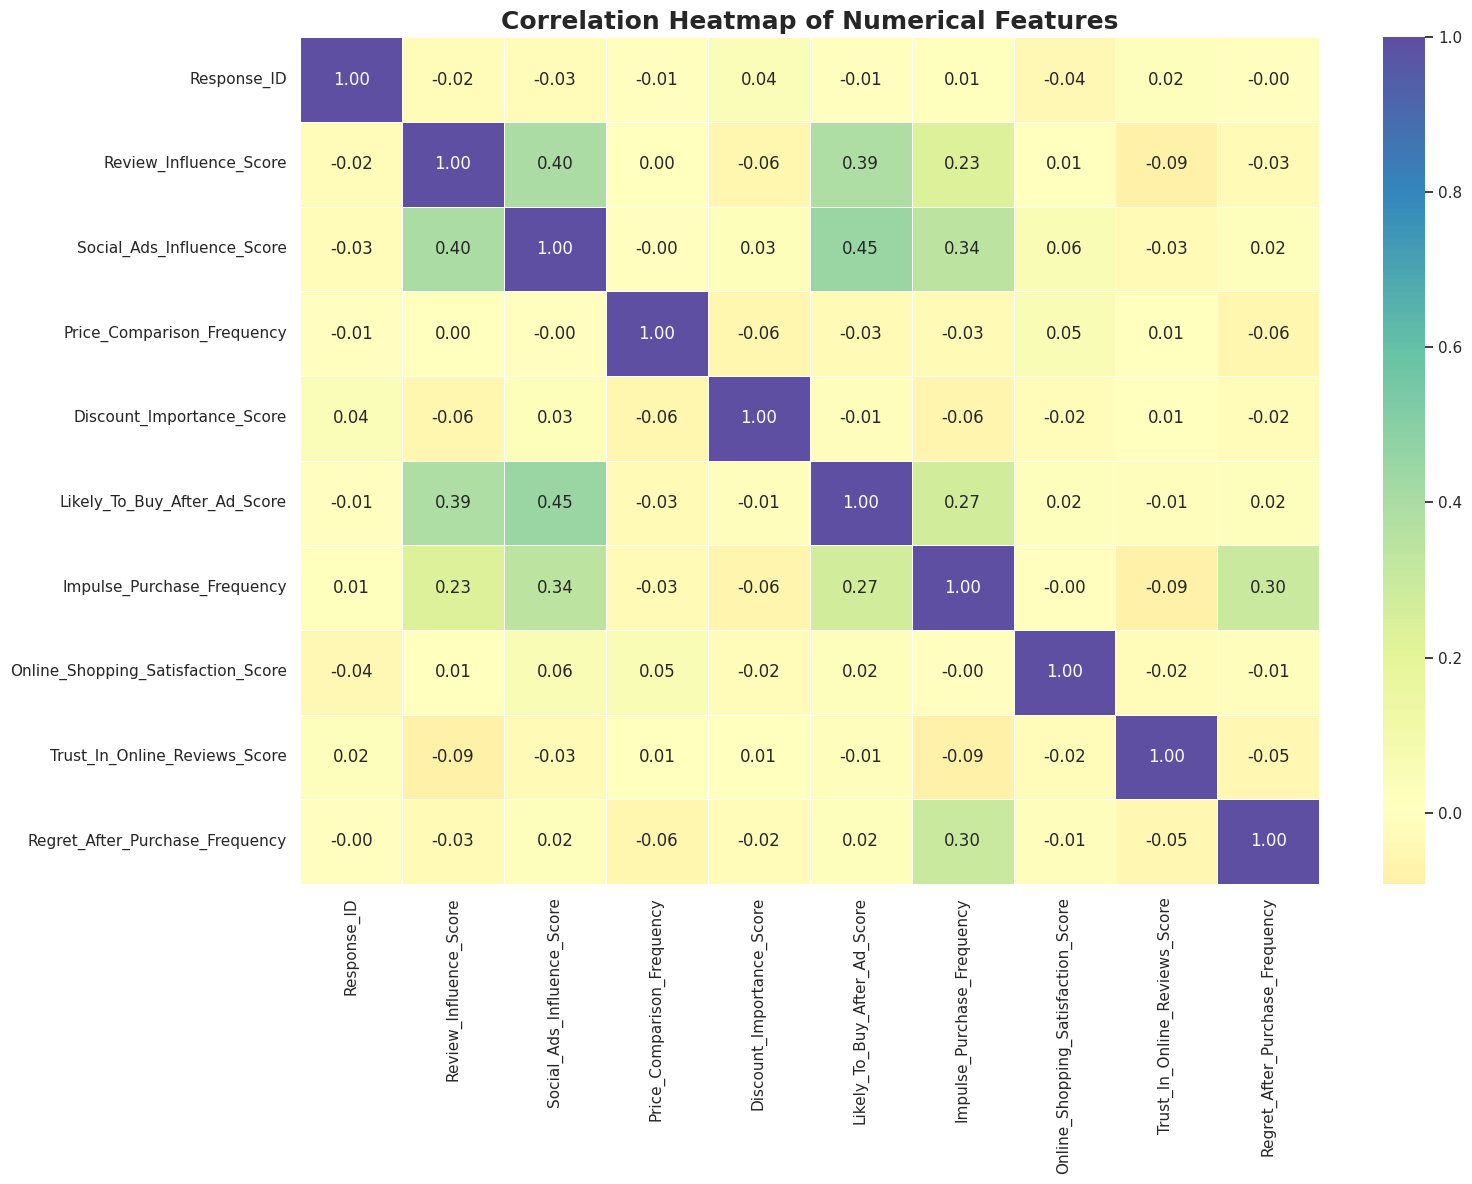

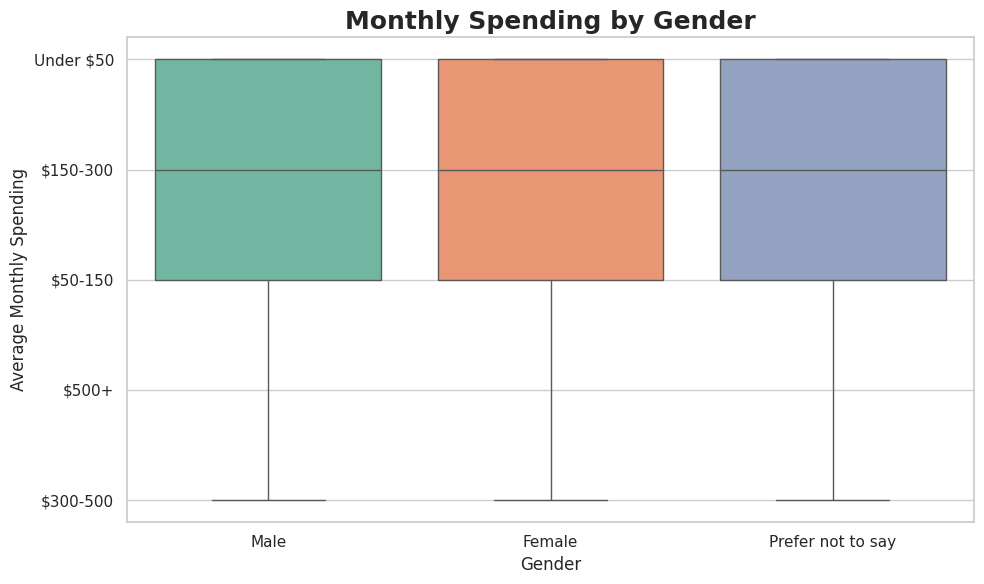

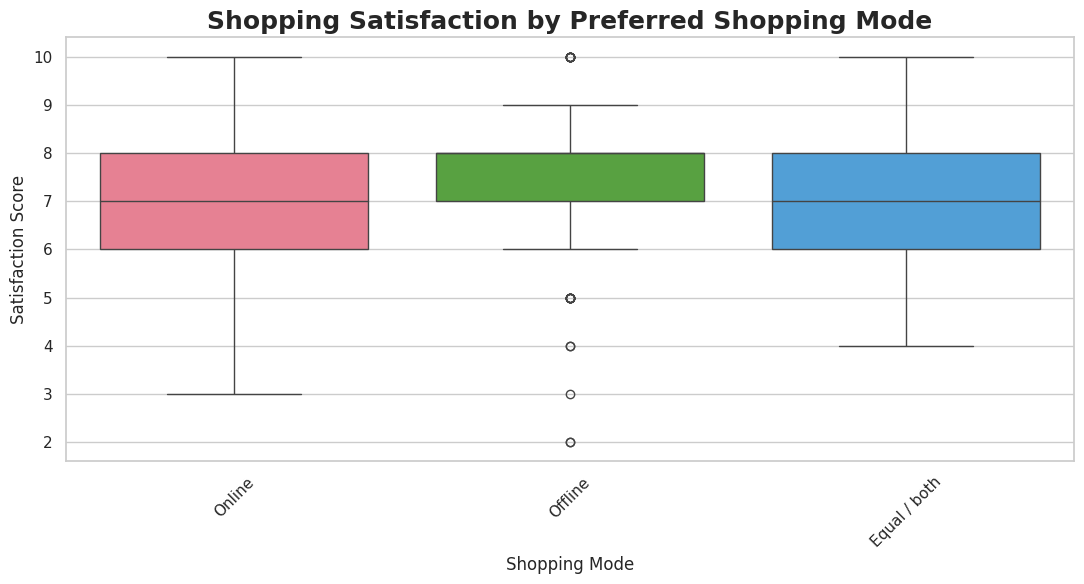


VISUALIZATION COMPLETED SUCCESSFULLY
Rows: 500
Columns: 30

Remaining NULL values: 0
Duplicate rows: 0

Numerical columns:
['Response_ID', 'Review_Influence_Score', 'Social_Ads_Influence_Score', 'Price_Comparison_Frequency', 'Discount_Importance_Score', 'Likely_To_Buy_After_Ad_Score', 'Impulse_Purchase_Frequency', 'Online_Shopping_Satisfaction_Score', 'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency']

Categorical columns:
['Timestamp', 'Age', 'Gender', 'Occupation_Status', 'Country_Region', 'Monthly_Income_Range', 'Shop_Most_Where', 'Online_Shopping_Frequency', 'Preferred_Platform', 'Primary_Device', 'Top_Spending_Category', 'Follows_Brands_On_Social', 'Makes_Shopping_List', 'Return_Frequency', 'Avg_Monthly_Spend_NonEssentials', 'Preferred_Payment_Method', 'Uses_BNPL_Installments', 'Reason_Prefer_Online', 'Reason_Prefer_InStore', 'Best_Shopping_Mode']


In [13]:
# ============================================================
# ONLINE SHOPPING BEHAVIOR - COLORFUL VISUALIZATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. COPY DATA
# ============================================================

data = df.copy()

# General style
sns.set_theme(style="whitegrid")

print("=" * 80)
print("DATASET SHAPE")
print("=" * 80)

print(data.shape)

print("\nColumns:")
print(data.columns.tolist())


# ============================================================
# 2. HANDLE BASIC NULL VALUES
# ============================================================

# Numerical columns
numeric_columns = data.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:
    data[col] = data[col].fillna(
        data[col].median()
    )


# Categorical columns
categorical_columns = data.select_dtypes(
    include=["object", "category"]
).columns

for col in categorical_columns:
    mode_value = data[col].mode()

    if len(mode_value) > 0:
        data[col] = data[col].fillna(
            mode_value.iloc[0]
        )
    else:
        data[col] = data[col].fillna("Unknown")


# ============================================================
# 3. AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="Age",
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title(
    "Age Distribution of Customers",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 4. GENDER DISTRIBUTION
# ============================================================

gender_count = data["Gender"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2")
)

plt.title(
    "Gender Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.show()


# ============================================================
# 5. OCCUPATION STATUS
# ============================================================

occupation_count = (
    data["Occupation_Status"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=occupation_count.values,
    y=occupation_count.index,
    hue=occupation_count.index,
    palette="viridis",
    legend=False
)

plt.title(
    "Customer Occupation Status",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Customers")
plt.ylabel("Occupation Status")

plt.tight_layout()
plt.show()


# ============================================================
# 6. COUNTRY / REGION
# ============================================================

country_count = (
    data["Country_Region"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=country_count.values,
    y=country_count.index,
    hue=country_count.index,
    palette="Spectral",
    legend=False
)

plt.title(
    "Top 15 Customer Regions",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Customers")
plt.ylabel("Country / Region")

plt.tight_layout()
plt.show()


# ============================================================
# 7. WHERE CUSTOMERS SHOP
# ============================================================

shop_count = (
    data["Shop_Most_Where"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=shop_count.index,
    y=shop_count.values,
    hue=shop_count.index,
    palette="Set1",
    legend=False
)

plt.title(
    "Where Customers Shop Most",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Shopping Location")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 8. ONLINE SHOPPING FREQUENCY
# ============================================================

frequency_count = (
    data["Online_Shopping_Frequency"]
    .value_counts()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=frequency_count.index,
    y=frequency_count.values,
    hue=frequency_count.index,
    palette="cool",
    legend=False
)

plt.title(
    "Online Shopping Frequency",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Shopping Frequency")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 9. PREFERRED PLATFORM
# ============================================================

platform_count = (
    data["Preferred_Platform"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=platform_count.values,
    y=platform_count.index,
    hue=platform_count.index,
    palette="plasma",
    legend=False
)

plt.title(
    "Most Preferred Shopping Platforms",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Customers")
plt.ylabel("Platform")

plt.tight_layout()
plt.show()


# ============================================================
# 10. PRIMARY DEVICE
# ============================================================

device_count = data["Primary_Device"].value_counts()

plt.figure(figsize=(9, 6))

plt.pie(
    device_count.values,
    labels=device_count.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("husl")
)

plt.title(
    "Primary Device Used for Shopping",
    fontsize=18,
    fontweight="bold"
)

plt.show()


# ============================================================
# 11. TOP SPENDING CATEGORY
# ============================================================

spending_count = (
    data["Top_Spending_Category"]
    .value_counts()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=spending_count.values,
    y=spending_count.index,
    hue=spending_count.index,
    palette="magma",
    legend=False
)

plt.title(
    "Top Spending Categories",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Customers")
plt.ylabel("Spending Category")

plt.tight_layout()
plt.show()


# ============================================================
# 12. MONTHLY NON-ESSENTIAL SPENDING
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="Avg_Monthly_Spend_NonEssentials",
    bins=25,
    kde=True,
    color="darkorange"
)

plt.title(
    "Monthly Non-Essential Spending Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Monthly Spend")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 13. SHOPPING SATISFACTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="Online_Shopping_Satisfaction_Score",
    bins=10,
    kde=True,
    color="mediumseagreen"
)

plt.title(
    "Online Shopping Satisfaction",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 14. TRUST IN ONLINE REVIEWS
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="Trust_In_Online_Reviews_Score",
    bins=10,
    kde=True,
    color="crimson"
)

plt.title(
    "Trust in Online Reviews",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Trust Score")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 15. REVIEW INFLUENCE VS PURCHASE AFTER AD
# ============================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=data,
    x="Review_Influence_Score",
    y="Likely_To_Buy_After_Ad_Score",
    hue="Gender",
    palette="Set1",
    alpha=0.7,
    s=80
)

plt.title(
    "Review Influence vs Likelihood to Buy After Advertisement",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Review Influence Score")
plt.ylabel("Likely to Buy After Ad Score")

plt.tight_layout()
plt.show()


# ============================================================
# 16. SOCIAL ADS INFLUENCE
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="Social_Ads_Influence_Score",
    bins=10,
    kde=True,
    color="purple"
)

plt.title(
    "Social Media Advertisement Influence",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Social Ads Influence Score")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 17. DISCOUNT IMPORTANCE
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=data,
    x="Discount_Importance_Score",
    hue="Discount_Importance_Score",
    palette="rainbow",
    legend=False
)

plt.title(
    "Importance of Discounts",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Discount Importance Score")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 18. IMPULSE PURCHASE FREQUENCY
# ============================================================

impulse_count = (
    data["Impulse_Purchase_Frequency"]
    .value_counts()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=impulse_count.index,
    y=impulse_count.values,
    hue=impulse_count.index,
    palette="cubehelix",
    legend=False
)

plt.title(
    "Impulse Purchase Frequency",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Impulse Purchase Frequency")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 19. RETURN FREQUENCY
# ============================================================

return_count = (
    data["Return_Frequency"]
    .value_counts()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=return_count.index,
    y=return_count.values,
    hue=return_count.index,
    palette="YlOrRd",
    legend=False
)

plt.title(
    "Product Return Frequency",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Return Frequency")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 20. PAYMENT METHOD
# ============================================================

payment_count = (
    data["Preferred_Payment_Method"]
    .value_counts()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=payment_count.index,
    y=payment_count.values,
    hue=payment_count.index,
    palette="Paired",
    legend=False
)

plt.title(
    "Preferred Payment Methods",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 21. BNPL USAGE
# ============================================================

bnpl_count = (
    data["Uses_BNPL_Installments"]
    .value_counts()
)

plt.figure(figsize=(8, 6))

plt.pie(
    bnpl_count.values,
    labels=bnpl_count.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)

plt.title(
    "BNPL Installment Usage",
    fontsize=18,
    fontweight="bold"
)

plt.show()


# ============================================================
# 22. SHOPPING MODE
# ============================================================

mode_count = (
    data["Best_Shopping_Mode"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=mode_count.index,
    y=mode_count.values,
    hue=mode_count.index,
    palette="Accent",
    legend=False
)

plt.title(
    "Preferred Shopping Mode",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Shopping Mode")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 23. AGE VS MONTHLY SPENDING
# ============================================================

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=data,
    x="Age",
    y="Avg_Monthly_Spend_NonEssentials",
    hue="Online_Shopping_Satisfaction_Score",
    palette="turbo",
    size="Online_Shopping_Satisfaction_Score",
    sizes=(30, 180),
    alpha=0.7
)

plt.title(
    "Age vs Monthly Non-Essential Spending",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Age")
plt.ylabel("Average Monthly Spending")

plt.tight_layout()
plt.show()


# ============================================================
# 24. CORRELATION HEATMAP
# ============================================================

numeric_columns = data.select_dtypes(
    include=np.number
).columns

correlation = data[
    numeric_columns
].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="Spectral",
    linewidths=0.5,
    center=0
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 25. BOXPLOT - SPENDING BY GENDER
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="Gender",
    y="Avg_Monthly_Spend_NonEssentials",
    hue="Gender",
    palette="Set2",
    legend=False
)

plt.title(
    "Monthly Spending by Gender",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Average Monthly Spending")

plt.tight_layout()
plt.show()


# ============================================================
# 26. SATISFACTION BY SHOPPING MODE
# ============================================================

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=data,
    x="Best_Shopping_Mode",
    y="Online_Shopping_Satisfaction_Score",
    hue="Best_Shopping_Mode",
    palette="husl",
    legend=False
)

plt.title(
    "Shopping Satisfaction by Preferred Shopping Mode",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Shopping Mode")
plt.ylabel("Satisfaction Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 27. FINAL DATA SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("VISUALIZATION COMPLETED SUCCESSFULLY")
print("=" * 80)

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

print(
    "\nRemaining NULL values:",
    data.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    data.duplicated().sum()
)

print("\nNumerical columns:")
print(
    data.select_dtypes(
        include=np.number
    ).columns.tolist()
)

print("\nCategorical columns:")
print(
    data.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)

## Features Engineering

DATASET INFORMATION
Shape: (500, 30)

Columns:
['Response_ID', 'Timestamp', 'Age', 'Gender', 'Occupation_Status', 'Country_Region', 'Monthly_Income_Range', 'Shop_Most_Where', 'Online_Shopping_Frequency', 'Preferred_Platform', 'Primary_Device', 'Top_Spending_Category', 'Review_Influence_Score', 'Social_Ads_Influence_Score', 'Price_Comparison_Frequency', 'Discount_Importance_Score', 'Follows_Brands_On_Social', 'Likely_To_Buy_After_Ad_Score', 'Makes_Shopping_List', 'Impulse_Purchase_Frequency', 'Return_Frequency', 'Avg_Monthly_Spend_NonEssentials', 'Preferred_Payment_Method', 'Uses_BNPL_Installments', 'Online_Shopping_Satisfaction_Score', 'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency', 'Reason_Prefer_Online', 'Reason_Prefer_InStore', 'Best_Shopping_Mode']

Duplicate rows: 0

FEATURE ENGINEERING

Engineered features created successfully!
['Age_Group', 'High_Spender', 'High_Review_Trust', 'High_Discount_Sensitivity', 'Ad_Influence_Level', 'Review_Influence_Level', 'Purch

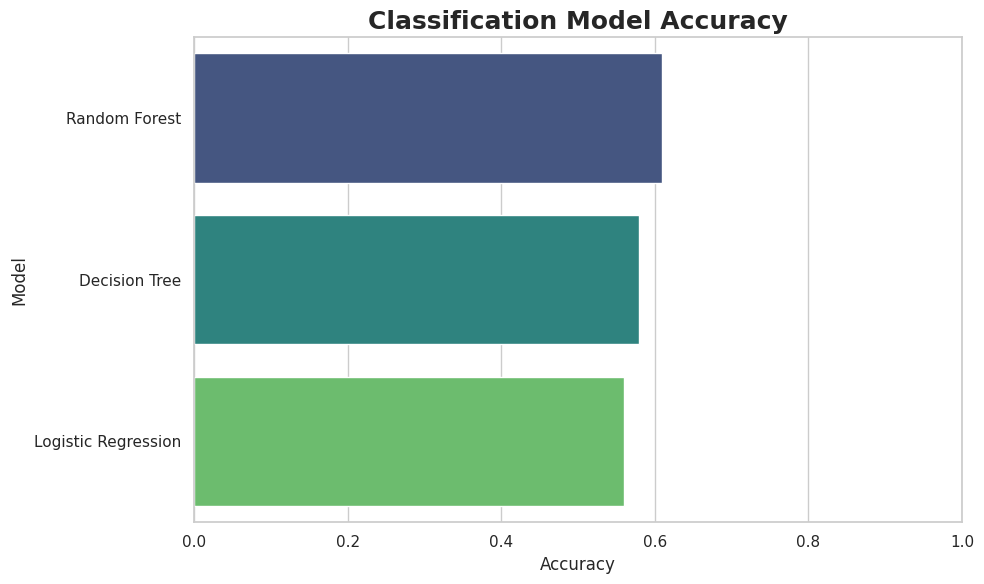

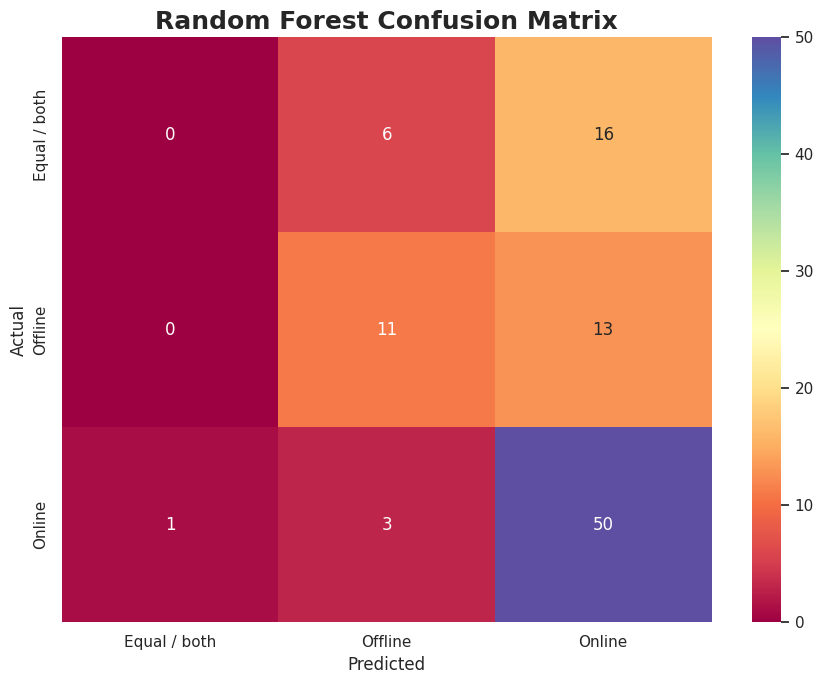

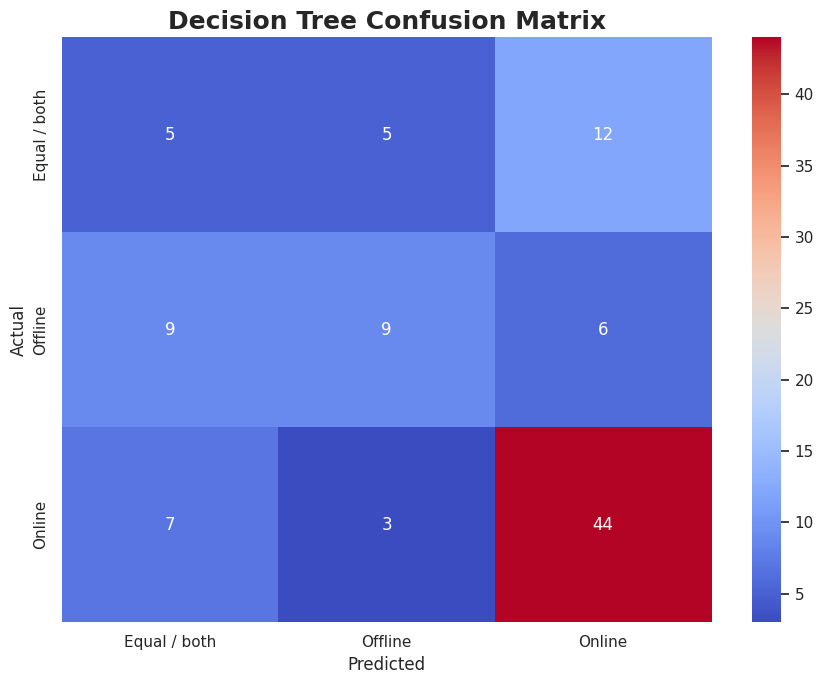


FINAL SUMMARY
Target: Best_Shopping_Mode
Training rows: 400
Testing rows: 100

Best Model: Random Forest
Best Accuracy: 0.61

Feature Engineering Completed ✓
Train/Test Split Completed ✓
Classification Completed ✓
Accuracy Calculation Completed ✓
Confusion Matrix Completed ✓


In [14]:
# ============================================================
# ONLINE SHOPPING BEHAVIOR
# FEATURE ENGINEERING + TRAIN TEST + CLASSIFICATION
# ACCURACY + CONFUSION MATRIX
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

sns.set_theme(style="whitegrid")


# ============================================================
# 1. COPY DATA
# ============================================================

data = df.copy()

print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print("Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())


# ============================================================
# 2. REMOVE DUPLICATES
# ============================================================

duplicate_count = data.duplicated().sum()

print("\nDuplicate rows:", duplicate_count)

data = data.drop_duplicates()

data.reset_index(drop=True, inplace=True)


# ============================================================
# 3. CONVERT NUMERICAL COLUMNS
# ============================================================

numeric_columns = [
    "Age",
    "Review_Influence_Score",
    "Social_Ads_Influence_Score",
    "Price_Comparison_Frequency",
    "Discount_Importance_Score",
    "Likely_To_Buy_After_Ad_Score",
    "Avg_Monthly_Spend_NonEssentials",
    "Online_Shopping_Satisfaction_Score",
    "Trust_In_Online_Reviews_Score",
    "Regret_After_Purchase_Frequency"
]

for col in numeric_columns:

    if col in data.columns:

        data[col] = pd.to_numeric(
            data[col],
            errors="coerce"
        )


# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================

print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)


# ------------------------------------------------------------
# Feature 1: Age Group
# ------------------------------------------------------------

data["Age_Group"] = pd.cut(
    data["Age"],
    bins=[
        0,
        18,
        25,
        35,
        45,
        60,
        np.inf
    ],
    labels=[
        "Under_18",
        "18_25",
        "26_35",
        "36_45",
        "46_60",
        "60_plus"
    ]
)


# ------------------------------------------------------------
# Feature 2: High Spender
# ------------------------------------------------------------

spending_median = data[
    "Avg_Monthly_Spend_NonEssentials"
].median()

data["High_Spender"] = (
    data["Avg_Monthly_Spend_NonEssentials"]
    >= spending_median
).astype(int)


# ------------------------------------------------------------
# Feature 3: High Review Trust
# ------------------------------------------------------------

trust_median = data[
    "Trust_In_Online_Reviews_Score"
].median()

data["High_Review_Trust"] = (
    data["Trust_In_Online_Reviews_Score"]
    >= trust_median
).astype(int)


# ------------------------------------------------------------
# Feature 4: High Discount Sensitivity
# ------------------------------------------------------------

discount_median = data[
    "Discount_Importance_Score"
].median()

data["High_Discount_Sensitivity"] = (
    data["Discount_Importance_Score"]
    >= discount_median
).astype(int)


# ------------------------------------------------------------
# Feature 5: Ad Influence Category
# ------------------------------------------------------------

data["Ad_Influence_Level"] = pd.cut(
    data["Social_Ads_Influence_Score"],
    bins=[
        -np.inf,
        2,
        4,
        np.inf
    ],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)


# ------------------------------------------------------------
# Feature 6: Review Influence Category
# ------------------------------------------------------------

data["Review_Influence_Level"] = pd.cut(
    data["Review_Influence_Score"],
    bins=[
        -np.inf,
        2,
        4,
        np.inf
    ],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)


# ------------------------------------------------------------
# Feature 7: Purchase Behavior Score
# ------------------------------------------------------------

data["Purchase_Behavior_Score"] = (
    data["Likely_To_Buy_After_Ad_Score"]
    +
    data["Discount_Importance_Score"]
    +
    data["Review_Influence_Score"]
)


# ------------------------------------------------------------
# Feature 8: Customer Trust Score
# ------------------------------------------------------------

data["Customer_Trust_Score"] = (
    data["Trust_In_Online_Reviews_Score"]
    +
    data["Online_Shopping_Satisfaction_Score"]
)


# ------------------------------------------------------------
# Feature 9: Shopping Risk Score
# ------------------------------------------------------------

data["Shopping_Risk_Score"] = (
    data["Impulse_Purchase_Frequency"]
    .astype(str)
    .factorize()[0]
)


print("\nEngineered features created successfully!")

print([
    "Age_Group",
    "High_Spender",
    "High_Review_Trust",
    "High_Discount_Sensitivity",
    "Ad_Influence_Level",
    "Review_Influence_Level",
    "Purchase_Behavior_Score",
    "Customer_Trust_Score",
    "Shopping_Risk_Score"
])


# ============================================================
# 5. TARGET VARIABLE
# ============================================================

target = "Best_Shopping_Mode"


# Remove rows where target is missing
data = data.dropna(
    subset=[target]
)


print("\n" + "=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

print(
    data[target].value_counts()
)


# ============================================================
# 6. REMOVE IDENTIFIER COLUMNS
# ============================================================

# Response_ID is an identifier and should not be used
# as a predictive feature.

columns_to_remove = [
    "Response_ID",
    "Timestamp"
]

data = data.drop(
    columns=[
        col
        for col in columns_to_remove
        if col in data.columns
    ]
)


# ============================================================
# 7. CREATE X AND y
# ============================================================

X = data.drop(
    columns=[target]
)

y = data[target]


print("\n" + "=" * 80)
print("FEATURES AND TARGET")
print("=" * 80)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget:", target)


# ============================================================
# 8. IDENTIFY NUMERICAL / CATEGORICAL FEATURES
# ============================================================

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()


print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# ============================================================
# 9. TRAIN TEST SPLIT
# ============================================================

# Stratify is used only when every class has at least
# two observations.

class_counts = y.value_counts()

if class_counts.min() >= 2:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

else:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )


print("\n" + "=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target :", y_test.shape)


# ============================================================
# 10. PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 11. LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)


logistic_model.fit(
    X_train,
    y_train
)


y_pred_lr = logistic_model.predict(
    X_test
)


accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)


print("\n" + "=" * 80)
print("LOGISTIC REGRESSION")
print("=" * 80)

print(
    "Accuracy:",
    round(accuracy_lr, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_lr,
        zero_division=0
    )
)


# ============================================================
# 12. DECISION TREE
# ============================================================

tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=8,
                random_state=42
            )
        )
    ]
)


tree_model.fit(
    X_train,
    y_train
)


y_pred_tree = tree_model.predict(
    X_test
)


accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)


print("\n" + "=" * 80)
print("DECISION TREE")
print("=" * 80)

print(
    "Accuracy:",
    round(accuracy_tree, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_tree,
        zero_division=0
    )
)


# ============================================================
# 13. RANDOM FOREST
# ============================================================

random_forest = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


random_forest.fit(
    X_train,
    y_train
)


y_pred_rf = random_forest.predict(
    X_test
)


accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)


print("\n" + "=" * 80)
print("RANDOM FOREST")
print("=" * 80)

print(
    "Accuracy:",
    round(accuracy_rf, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)


# ============================================================
# 14. MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_tree,
        accuracy_rf
    ]
})


results = results.sort_values(
    "Accuracy",
    ascending=False
)


print("\n" + "=" * 80)
print("MODEL ACCURACY COMPARISON")
print("=" * 80)

print(
    results.to_string(index=False)
)


# ============================================================
# 15. ACCURACY VISUALIZATION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.xlim(0, 1)

plt.title(
    "Classification Model Accuracy",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.tight_layout()
plt.show()


# ============================================================
# 16. CONFUSION MATRIX - RANDOM FOREST
# ============================================================

labels = sorted(
    y_test.unique()
)

cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=labels
)


plt.figure(
    figsize=(9, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Spectral",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ============================================================
# 17. CONFUSION MATRIX - DECISION TREE
# ============================================================

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree,
    labels=labels
)


plt.figure(
    figsize=(9, 7)
)

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Decision Tree Confusion Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print(
    "Target:",
    target
)

print(
    "Training rows:",
    len(X_train)
)

print(
    "Testing rows:",
    len(X_test)
)

print(
    "\nBest Model:",
    results.iloc[0]["Model"]
)

print(
    "Best Accuracy:",
    round(
        results.iloc[0]["Accuracy"],
        4
    )
)

print("\nFeature Engineering Completed ✓")
print("Train/Test Split Completed ✓")
print("Classification Completed ✓")
print("Accuracy Calculation Completed ✓")
print("Confusion Matrix Completed ✓")

## Thanks........Please Upvote